In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import roc_curve, roc_auc_score, auc

In [6]:
# Cargar dataset
df = pd.read_csv("../data/dataset_supervisado.csv", encoding='latin1', sep=';', low_memory=False)
df.head()

,"id_registro,edad,dias_ini_not,n_sintomas,n_comorbilidades,fiebre,malestar,tos,garganta,congestion,respiratoria,diarrea,nauseas,cefalea,irritabilidad,muscular,abdominal,pecho,articulaciones,disnea,auscultacion,rxpulmonar,exudado,conjuntival,convulsion,cardiovascular,diabetes,hepatica,neurologica,inmunodeficiencia,renal,pulmonar,cancer,embarazo,sexo,etnia,ocupacion,red,institucion,obesidad,anosmia_ageusia,ola,ventilacion,entubado,neumonia,servicio,hospitalizado,fallecido,particion"
0,"0,49.0,0.0,4,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0..."
1,"1,46.0,0.0,2,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0..."
2,"2,46.0,6.0,6,0,1,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0..."
3,"3,63.0,5.0,4,0,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0..."
4,"4,25.0,2.0,4,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0..."


Regresión Logística: Predicción de Defunción

In [13]:
df = pd.read_csv("../data/dataset_supervisado.csv", encoding='latin1', sep=',', low_memory=False)
# Contar los valores únicos en la columna 'fallecido'
fallecido_counts = df['fallecido'].value_counts(dropna=False)
print("Valores únicos en la columna 'fallecido':\n", fallecido_counts)

Valores únicos en la columna 'fallecido':
 fallecido
0    47551
1     1964
Name: count, dtype: int64


Preparación de Datos para Regresión Logística

In [9]:
# Crear la variable objetivo binaria 'es_fallecido'.
df['es_fallecido'] = df['fallecido'].astype(int)
# Asegurémonos de que el 'hospitalizado' es tratado como categórico.
df['hospitalizado'] = df['hospitalizado'].astype('category')
df_processed = pd.get_dummies(df, columns=['hospitalizado'], prefix='hospitalizado', dummy_na=False)

# Definir las características para X.
features_base = ['edad']
hospitalizado_cols = [col for col in df_processed.columns if col.startswith('hospitalizado_')]

features = features_base + hospitalizado_cols

X = df_processed[features].copy()
y = df_processed['es_fallecido'].copy()


data_logistic = pd.concat([X, y], axis=1)

X_clean_logistic = data_logistic[features]
y_clean_logistic = data_logistic['es_fallecido']

print(f"Dimensiones de los datos después de la limpieza para regresión logística: {X_clean_logistic.shape}")
print("Conteo de la variable objetivo 'es_fallecido' después de la limpieza:")
print(y_clean_logistic.value_counts())
display(data_logistic.head())

Dimensiones de los datos después de la limpieza para regresión logística: (49515, 4)
Conteo de la variable objetivo 'es_fallecido' después de la limpieza:
es_fallecido
0    47551
1     1964
Name: count, dtype: int64


,edad,hospitalizado_DESCONOCIDO,hospitalizado_NO,hospitalizado_SI,es_fallecido
0,49.0,False,True,False,0
1,46.0,False,True,False,0
2,46.0,False,True,False,0
3,63.0,False,True,False,0
4,25.0,False,True,False,0


Dividir los datos en conjuntos de entrenamiento y prueba

In [10]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_clean_logistic, y_clean_logistic, test_size=0.2, random_state=42, stratify=y_clean_logistic)

print(f"Tamaño del conjunto de entrenamiento (X_train_log): {X_train_log.shape}")
print(f"Tamaño del conjunto de prueba (X_test_log): {X_test_log.shape}")
print("Conteo de la variable objetivo en el conjunto de entrenamiento:")
print(y_train_log.value_counts(normalize=True))
print("Conteo de la variable objetivo en el conjunto de prueba:")
print(y_test_log.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento (X_train_log): (39612, 4)
Tamaño del conjunto de prueba (X_test_log): (9903, 4)
Conteo de la variable objetivo en el conjunto de entrenamiento:
es_fallecido
0    0.96034
1    0.03966
Name: proportion, dtype: float64
Conteo de la variable objetivo en el conjunto de prueba:
es_fallecido
0    0.960315
1    0.039685
Name: proportion, dtype: float64


Inicializar y entrenar el modelo de Regresión Logística

In [11]:
scaler = StandardScaler()
X_train_scaled_log = scaler.fit_transform(X_train_log)
X_test_scaled_log = scaler.transform(X_test_log)

# class_weight para intentar mitigar el desequilibrio de clases en los datos
logistic_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
logistic_model.fit(X_train_scaled_log, y_train_log)

print("Modelo de Regresión Logística entrenado.")
print(f"Coeficientes: {logistic_model.coef_}")
print(f"Intercepto: {logistic_model.intercept_}")

Modelo de Regresión Logística entrenado.
Coeficientes: [[ 1.30535867  0.04927789 -0.55473003  0.55263039]]
Intercepto: [-1.90654768]


Creacion de la prediccion y el conjunto de prueba

Accuracy: 0.90
Precision: 0.27
Recall: 0.89
F1-Score: 0.42
ROC AUC Score: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.95      9510
           1       0.27      0.89      0.42       393

    accuracy                           0.90      9903
   macro avg       0.63      0.89      0.68      9903
weighted avg       0.97      0.90      0.93      9903


Matriz de Confusión:


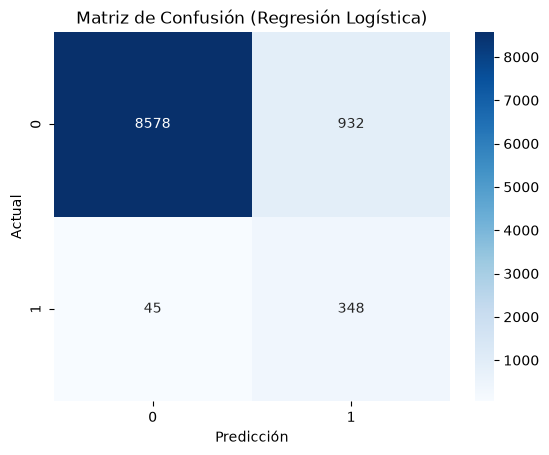

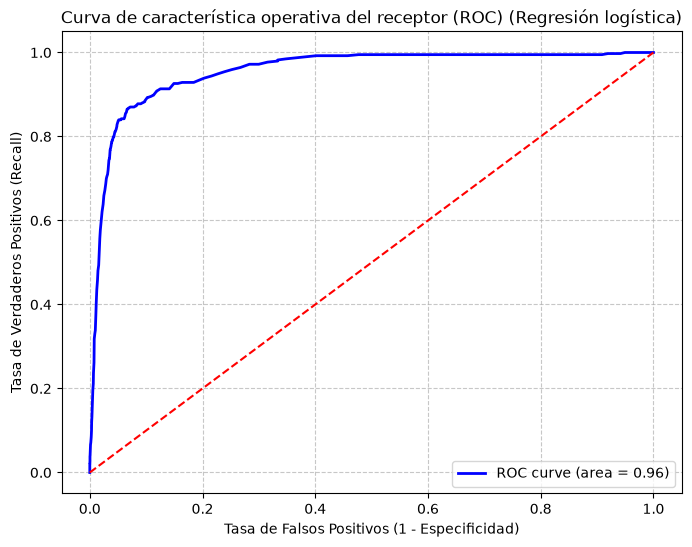

In [ ]:
y_pred_log = logistic_model.predict(X_test_scaled_log)
y_pred_proba_log = logistic_model.predict_proba(X_test_scaled_log)[:, 1]

# Evaluar el modelo
accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)
roc_auc = roc_auc_score(y_test_log, y_pred_proba_log)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC AUC Score: {roc_auc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

print("\nMatriz de Confusión:")
conf_matrix = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Actual')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_log, y_pred_proba_log)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva de característica operativa del receptor (ROC) (Regresión logística)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()